# AG-HYPOPT · Trial 27

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-six trials are registered; cell 2 reports `phase = trials` (26/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, balanced gamma (`lr_gamma=0.4716`, `gamma_anneal=0.4723`); 0 div.
- next best (all 0 div): trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138).
- plateau: trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- larger travel: trial_11 0.1188 (0.159).
- diverging: trial_26 0.1368 (0.137, **1nW T05**, despite being a near-copy of trial_21), trial_17 0.1329 (0.088), trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: the best is a narrow spike at travel ~0.137-0.138 with balanced gamma knobs. Trial_26 is the key new result: a near-exact resample of trial_21 (all knobs within ~0.007, travel 0.137) still diverged at 1nW T05, so the low-count gamma blow-up is essentially unpredictable at this resolution and trial_21's 0.1074 may be partly lucky. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_27'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (26/5 trials)
ID |     ei | params
 1 | 0.6203 | {"gamma_anneal": 0.5429028844814201, "lr_gamma": 0.3574119455334212, "lr_mu": 0.15975352192571904, "mu_anneal": 0.19893321718647516}
 2 | 2.4034 | {"gamma_anneal": 0.4699851856385777, "lr_gamma": 0.44574130578024557, "lr_mu": 0.15998465284971114, "mu_anneal": 0.3380346434692033}
 3 | 3.1993 | {"gamma_anneal": 0.5098816957362503, "lr_gamma": 0.4385381213721313, "lr_mu": 0.1597158923476971, "mu_anneal": 0.3449132425611384}
 4 | 1.0869 | {"gamma_anneal": 0.5203875578383328, "lr_gamma": 0.8956551668842466, "lr_mu": 0.1597299406143112, "mu_anneal": 0.3309356436590859}
 5 | 3.8495 | {"gamma_anneal": 0.5009664762902103, "lr_gamma": 0.45466806844750135, "lr_mu": 0.23496333044391654, "mu_anneal": 0.35108523499068545}
 6 | 3.2050 | {"gamma_anneal": 0.895211642286357, "lr_gamma": 0.4543705023854755, "lr_mu": 0.17379769526755043, "mu_anneal": 0.3504520381966436}
 7 | 0.8467 | {"gamma_anneal": 0.5418168128378256, "lr_gamma": 0.1033821

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (26 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 5: **ei 3.85** — `lr_mu=0.2350`, `mu_anneal=0.3511` (travel **0.194**), `lr_gamma=0.4547`, `gamma_anneal=0.5010`.
- candidate 6: ei 3.21 — `lr_mu=0.1738`, `mu_anneal=0.3505` (travel 0.143), `lr_gamma=0.4544`, `gamma_anneal=0.8952` (high).
- candidate 3: ei 3.20 — `lr_mu=0.1597`, `mu_anneal=0.3449` (travel 0.132), `lr_gamma=0.4385`, `gamma_anneal=0.5099`.
- candidate 8: ei 2.71 — `lr_mu=0.1648`, `mu_anneal=0.3447` (travel 0.136), `lr_gamma=0.5657`, `gamma_anneal=0.4991`.
- candidate 2: ei 2.40 — `lr_mu=0.1600`, `mu_anneal=0.3380` (travel 0.133), `lr_gamma=0.4457`, `gamma_anneal=0.4700`.

Candidate 5 has the highest ei and is the only top candidate outside the current optimum, at travel 0.194 — between trial_11 (0.159, obj 0.1188) and trial_02 (0.264, obj 0.1449). That region is empirically worse than the optimum, but it is sparsely sampled at 0.19 and the surrogate rates it highly, so it is an informative probe of whether a second lower region exists beyond the current spike. The alternatives (candidates 3, 8, 2) are ordinary resamples of the already well-mapped optimum (travel 0.132-0.136) with lower ei; candidate 6 has a high `gamma_anneal=0.895`. Given the optimum is thoroughly characterised and trial_26 showed the neighbourhood is noisy, the maximum-ei candidate 5 is the most informative next use of a trial.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5009664762902103, 'lr_gamma': 0.45466806844750135, 'lr_mu': 0.23496333044391654, 'mu_anneal': 0.35108523499068545}
Running  1nW Trans05 ... 

μ 9.39 -> 11.27 | γ 8.5 -> 4.32 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 53.92 | γ 8.5 -> 6.23 | NLL 5.75


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 83.02 | γ 14.1 -> 14.68 | NLL 3.76


Running 3nW Trans100 ... 

μ 175.71 -> 114.83 | γ 14.1 -> 13.86 | NLL 3.30



Total: 8.7 min


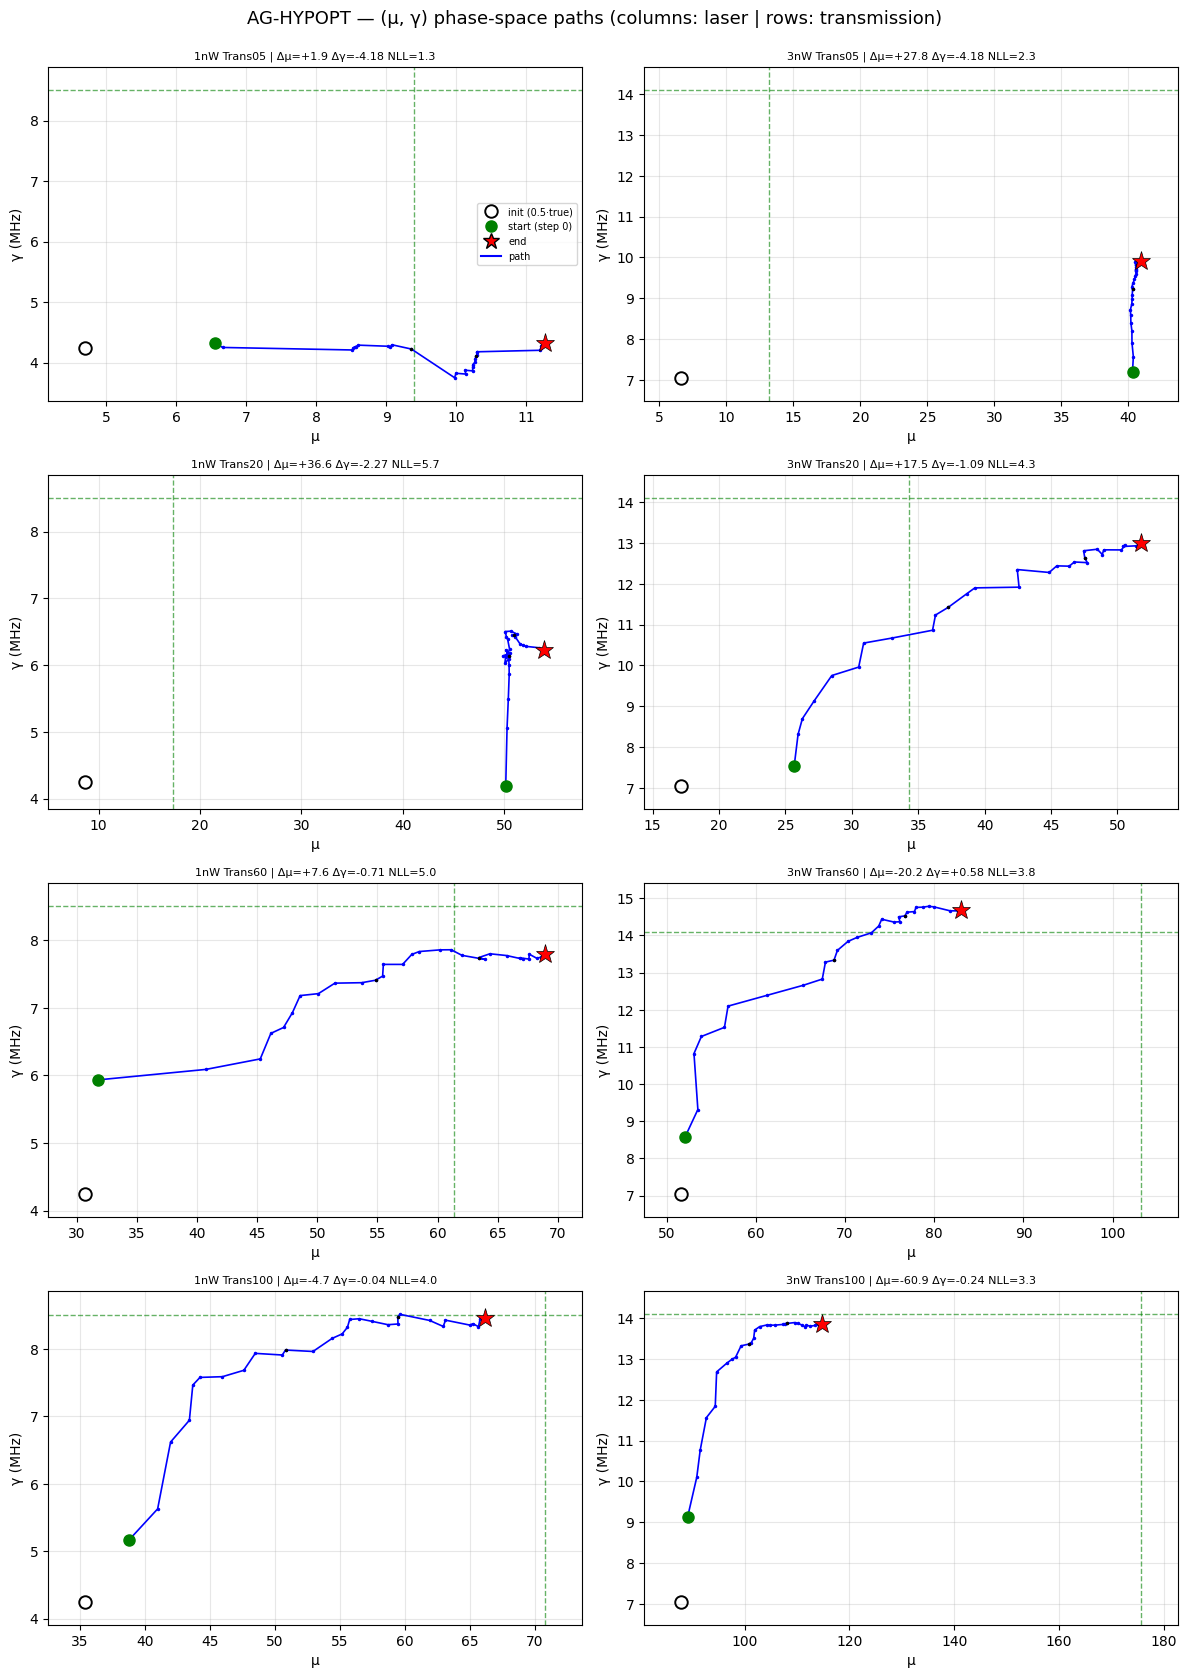

trial finished in 8.7 min
objective = 0.1149 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.27   +20.0 |     8.50    4.32   -49.1
1nW Trans20       17.32   53.92  +211.4 |     8.50    6.23   -26.7
1nW Trans60       61.37   68.95   +12.3 |     8.50    7.79    -8.4
1nW Trans100       70.82   66.15    -6.6 |     8.50    8.46    -0.4
3nW Trans05       13.20   40.95  +210.2 |    14.10    9.92   -29.7
3nW Trans20       34.28   51.79   +51.1 |    14.10   13.01    -7.8
3nW Trans60      103.20   83.02   -19.6 |    14.10   14.68    +4.1
3nW Trans100      175.71  114.83   -34.6 |    14.10   13.86    -1.7

weighted objective (T-graded, cap=1.0) = 0.1149 | diverged cells: 0
μ: RMSE 28.751 (rel 108.2%, bias +0.700) | γ: RMSE 2.296 (rel 22.8%, bias -1.516)


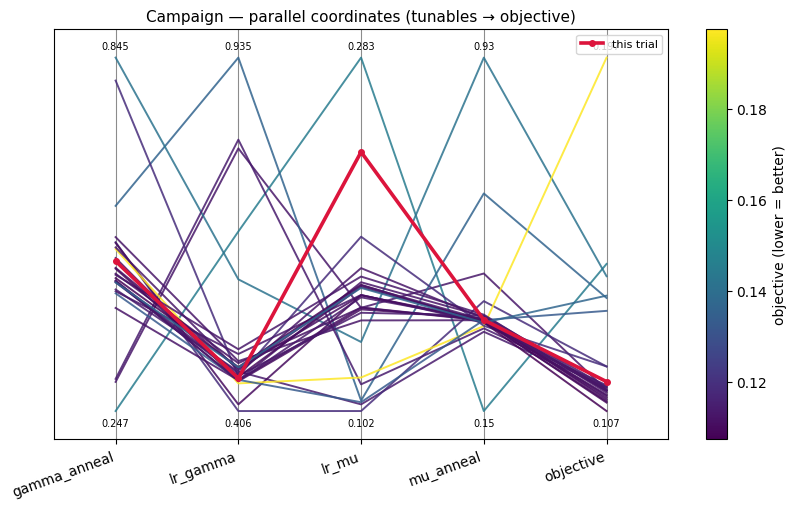

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 27 ran the highest-EI candidate (candidate 5, ei=3.85): `lr_mu=0.2350`, `mu_anneal=0.3511` (effective mu travel 0.194), `lr_gamma=0.4547`, `gamma_anneal=0.5010`. It completed in 8.7 min with objective **0.1149 +/- 0.0825** and **0 diverged cells**. Ranking: trial_21 0.1074 < ... < **trial_27 0.1149** (between trial_07's 0.1140 and trial_11's 0.1188) < ...

Aggregate accuracy: **mu rel-RMSE 108.2%** (RMSE 28.75, bias +0.70 — the largest mu error of any divergence-free run); **gamma rel-RMSE 22.8%** (RMSE 2.30, bias -1.52).

Per-cell relative errors:
- **mu:** 1nW T05 +20.0%, T20 **+211.4%**, T60 +12.3%, T100 -6.6% | 3nW T05 **+210.2%**, T20 +51.1%, T60 -19.6%, T100 -34.6%.
- **gamma:** 1nW T05 -49.1%, T20 -26.7%, T60 -8.4%, T100 -0.4% | 3nW T05 -29.7%, T20 -7.8%, T60 +4.1%, T100 -1.7%.

This probed the larger-travel region (0.194) that had been sparsely sampled, and it delivered a safe but clearly worse result: 0.1149, with the mid-T mu overshoots ballooning (1nW T20 +211.4%, 3nW T05 +210.2%). It is less bad than trial_11 (0.1188 at travel 0.159) but worse than the optimum, so the objective rises as travel moves away from ~0.137 in this direction and there is **no second lower region**. Combined with the low-travel side (trials 03/04/06 worse and/or diverging), the picture is a single optimum spike at travel ~0.137-0.138, with everything else monotonically worse. trial_21 (0.1074) remains the best.

**Summary:** Trial 27 (lr_mu=0.2350, mu_anneal=0.3511, lr_gamma=0.4547, gamma_anneal=0.5010): objective 0.1149 +/- 0.0825 with 0 diverged cells; the large-travel probe (0.194) gave a safe but worse run (mid-T mu overshoots +211%), so no second lower region exists and trial_21 (0.1074) stays best.
**Key insight:** Travel 0.194 (between trial_11's 0.159 and trial_02's 0.264) lands at 0.1149 with huge mid-T overshoots, confirming the objective rises monotonically away from the ~0.137 optimum - the larger-travel region offers nothing.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Both sides of the optimum are now mapped: low travel (<0.10) gives 0.1135-0.1188 with sporadic divergences, large travel (0.16-0.26) gives 0.1149-0.1449, and the single best spike is at 0.137-0.138. The campaign has fully characterised the 1-D mu-travel axis; remaining differences are the small-cell/divergence noise. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 27 (lr_mu=0.2350, mu_anneal=0.3511, lr_gamma=0.4547, gamma_anneal=0.5010): objective 0.1149 +/- 0.0825 with 0 diverged cells; the large-travel probe (0.194) gave a safe but worse run (mid-T mu overshoots +211%), so no second lower region exists and trial_21 (0.1074) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Travel 0.194 (between trial_11's 0.159 and trial_02's 0.264) lands at 0.1149 with huge mid-T overshoots, confirming the objective rises monotonically away from the ~0.137 optimum - the larger-travel region offers nothing"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_27 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_28.ipynb. Open it and follow its cells from the top.
